# Exploratory Data Analysis (EDA)

Notebook for EDA: temperature trend, precipitation distribution, correlation heatmap, and monthly seasonality. All charts are exported to `reports/`.

## 1) Imports and setup

In [8]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

## 2) Load data and build analysis frame

We load the **raw CSV** so temperature/precipitation stay in physical units and `timezone`/`continent` remain available. The cleaned parquet is optimized for modeling, not exploratory plots.

In [9]:
# Use RAW CSV for EDA. The cleaned parquet is one-hot encoded + MinMax scaled, which breaks
# interpretability (temperature in 0–1, no string timezone, huge column count).
raw_path = project_root / "data" / "raw" / "GlobalWeatherRepository.csv"
df = pd.read_csv(raw_path, parse_dates=["last_updated"])
df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")
source_name = "GlobalWeatherRepository.csv (raw)"

if "last_updated" not in df.columns:
    if "last_updated_epoch" in df.columns:
        df["last_updated"] = pd.to_datetime(df["last_updated_epoch"], unit="s", errors="coerce")
    else:
        raise ValueError("No temporal column found.")

# Region strategy: continent column if present and populated; else IANA timezone area (before '/').
if "continent" in df.columns and df["continent"].notna().any():
    df["region"] = df["continent"].astype(str)
elif "timezone" in df.columns:
    df["region"] = df["timezone"].astype(str).str.split("/").str[0]
else:
    df["region"] = "Unknown"

# Robust precipitation column selection (dataset naming can vary).
precip_candidates = [
    "precip_mm",
    "precipitation_mm",
    "precipitation",
    "precip_in",
]
precip_col = next((c for c in precip_candidates if c in df.columns), None)
if precip_col is None:
    raise ValueError(f"No precipitation column found. Tried: {precip_candidates}")

# Temperature selection for EDA.
temp_candidates = ["temperature_celsius", "temp_c", "temperature"]
temp_col = next((c for c in temp_candidates if c in df.columns), None)
if temp_col is None:
    raise ValueError(f"No temperature column found. Tried: {temp_candidates}")

# Keep valid rows for time analysis.
eda = df.dropna(subset=["last_updated", temp_col]).copy()
eda["year_month"] = eda["last_updated"].dt.to_period("M").astype(str)
eda["month"] = eda["last_updated"].dt.month

print("Source:", source_name)
print("EDA shape:", eda.shape)
print("Temperature column:", temp_col)
print("Precipitation column:", precip_col)
eda[["last_updated", "region", temp_col, precip_col]].head()

Source: GlobalWeatherRepository.csv (raw)
EDA shape: (133318, 44)
Temperature column: temperature_celsius
Precipitation column: precip_mm


,last_updated,region,temperature_celsius,precip_mm
0,2024-05-16 13:15:00,Asia,26.6,0.0
1,2024-05-16 10:45:00,Europe,19.0,0.1
2,2024-05-16 09:45:00,Africa,23.0,0.0
3,2024-05-16 10:45:00,Europe,6.3,0.3
4,2024-05-16 09:45:00,Africa,26.0,0.0


## 3) Chart 1 — Temperature trend over time by region

In [10]:
temp_monthly = (
    eda.groupby(["year_month", "region"], as_index=False)[temp_col]
    .mean()
    .sort_values("year_month")
)

fig1 = px.line(
    temp_monthly,
    x="year_month",
    y=temp_col,
    color="region",
    title="Average Temperature Trend by Region (Monthly)",
    labels={"year_month": "Year-Month", temp_col: "Avg Temperature", "region": "Region"},
)
fig1.update_layout(legend_title_text="Region")
_html_out = reports_dir / "eda_temperature_trend_by_region.html"
fig1.write_html(_html_out)
print("Saved:", _html_out)
# Open the HTML file in a browser if inline Plotly is unavailable (requires nbformat in Jupyter).
try:
    fig1.show()
except ValueError as exc:
    if "nbformat" in str(exc).lower():
        print("Plotly inline skipped. Install: pip install 'nbformat>=4.2.0' — or open the HTML file above.")
    else:
        raise

Saved: c:\Users\lucas\Desktop\pma-weather-forecasting\reports\eda_temperature_trend_by_region.html


**Interpretation (Chart 1):**
- Compare regional curves to identify warmer/cooler regimes and possible seasonal shifts.
- Large divergence between regions may suggest different climate baselines or sampling imbalance.

## 4) Chart 2 — Precipitation distribution by continent/region

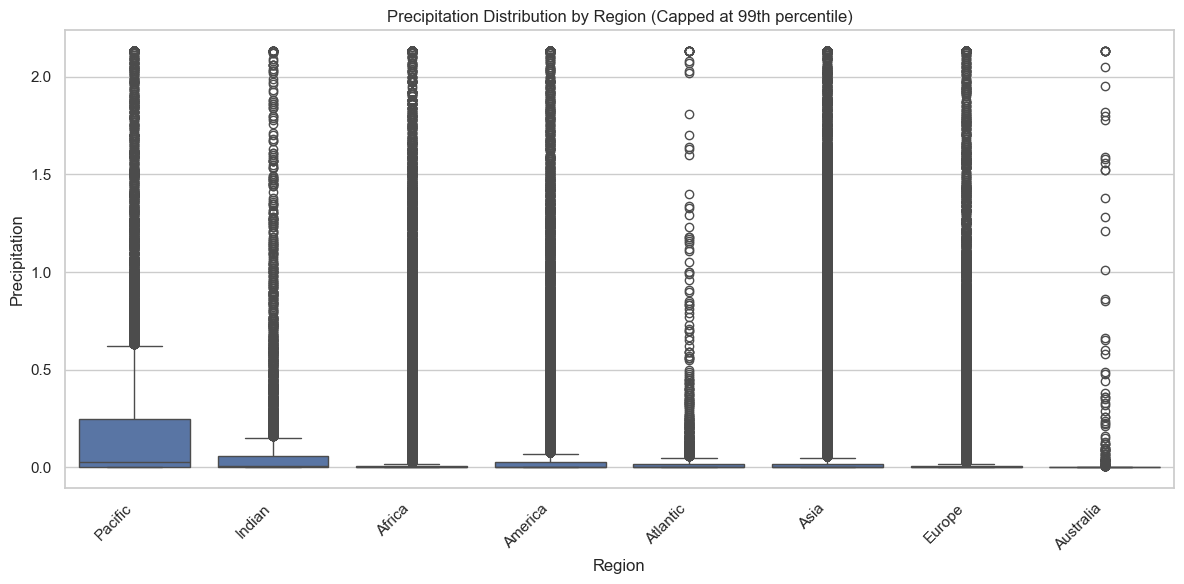

In [11]:
precip_sample = eda[["region", precip_col]].dropna().copy()
# Cap extreme tail for readability in boxplot visualization.
upper_cap = precip_sample[precip_col].quantile(0.99)
precip_sample[precip_col] = precip_sample[precip_col].clip(upper=upper_cap)

plt.figure(figsize=(12, 6))
order = precip_sample.groupby("region")[precip_col].median().sort_values(ascending=False).index
sns.boxplot(data=precip_sample, x="region", y=precip_col, order=order)
plt.title("Precipitation Distribution by Region (Capped at 99th percentile)")
plt.xlabel("Region")
plt.ylabel("Precipitation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(reports_dir / "eda_precipitation_distribution_by_region.png", dpi=150)
plt.show()

**Interpretation (Chart 2):**
- Median and spread differences indicate where rainfall is more stable vs volatile.
- Wide IQR and long tails can indicate frequent extreme precipitation events in specific regions.

## 5) Chart 3 — Correlation heatmap + 3D surface

Static **heatmap** (Seaborn) for quick reading of *r* values; **3D surface** (Plotly) for the same matrix — useful to see “ridges” of strong correlation and rotate the view in the exported HTML.

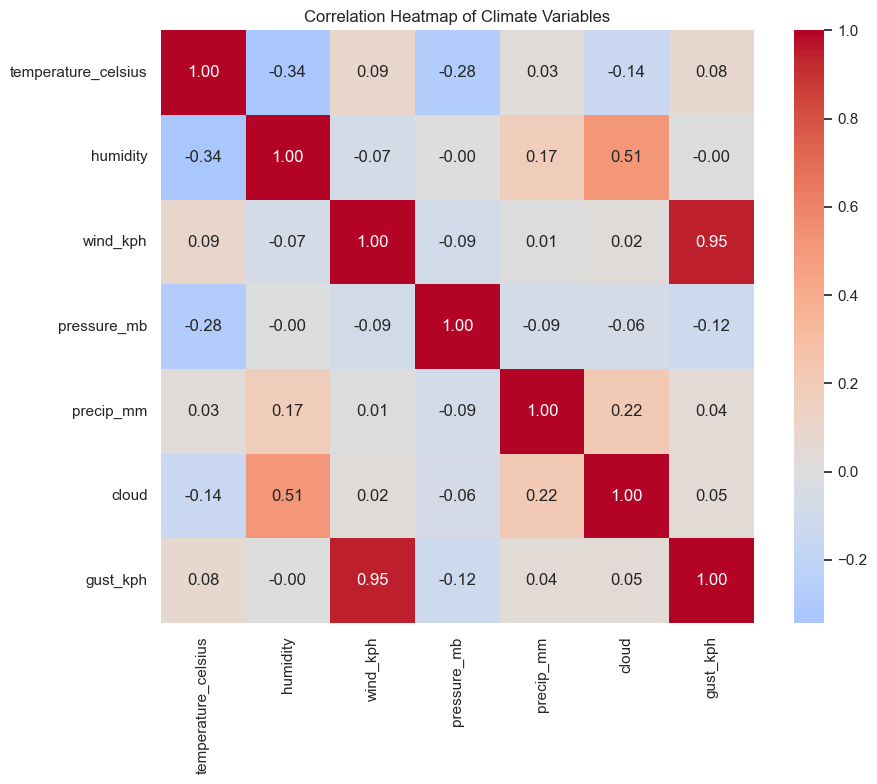

Saved: c:\Users\lucas\Desktop\pma-weather-forecasting\reports\eda_correlation_surface_3d.html


In [12]:
numeric_cols = eda.select_dtypes(include=[np.number]).columns.tolist()

# Keep a focused set of interpretable weather metrics when available.
priority_vars = [
    "temperature_celsius",
    "humidity",
    "wind_kph",
    "pressure_mb",
    "precip_mm",
    "cloud",
    "uv",
    "gust_kph",
]
selected_numeric = [c for c in priority_vars if c in numeric_cols]
if len(selected_numeric) < 4:
    selected_numeric = numeric_cols[:12]

corr = eda[selected_numeric].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Climate Variables")
plt.tight_layout()
plt.savefig(reports_dir / "eda_correlation_heatmap.png", dpi=150)
plt.show()
plt.close()

# 3D surface: same correlation matrix (interactive rotation in exported HTML)
labels = [str(c)[:24] for c in corr.columns]
z = corr.values.astype(float)
n = z.shape[0]
fig3d = go.Figure(
    data=[
        go.Surface(
            z=z,
            colorscale="RdBu",
            cmin=-1,
            cmax=1,
            colorbar=dict(title="r"),
        )
    ]
)
fig3d.update_layout(
    title="Correlation matrix — 3D surface (z = Pearson r)",
    scene=dict(
        xaxis=dict(
            tickmode="array",
            tickvals=list(range(n)),
            ticktext=labels,
            title="Column index",
        ),
        yaxis=dict(
            tickmode="array",
            tickvals=list(range(n)),
            ticktext=labels,
            title="Row index",
        ),
        zaxis=dict(title="Correlation"),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=0.55),
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    height=700,
)
out3d = reports_dir / "eda_correlation_surface_3d.html"
fig3d.write_html(out3d)
print("Saved:", out3d)
try:
    fig3d.show()
except ValueError as exc:
    if "nbformat" in str(exc).lower():
        print("Open the HTML file to rotate the 3D surface interactively.")
    else:
        raise

**Interpretation (Chart 3):**
- Positive/negative correlation blocks highlight coupled weather dynamics.
- Strong correlations can guide feature selection and multicollinearity checks for modeling.
- The 3D surface encodes the same matrix: higher *z* peaks show stronger pairwise correlation for those variable pairs (open the HTML to inspect oblique views).

## 6) Chart 4 — Monthly seasonality of temperature

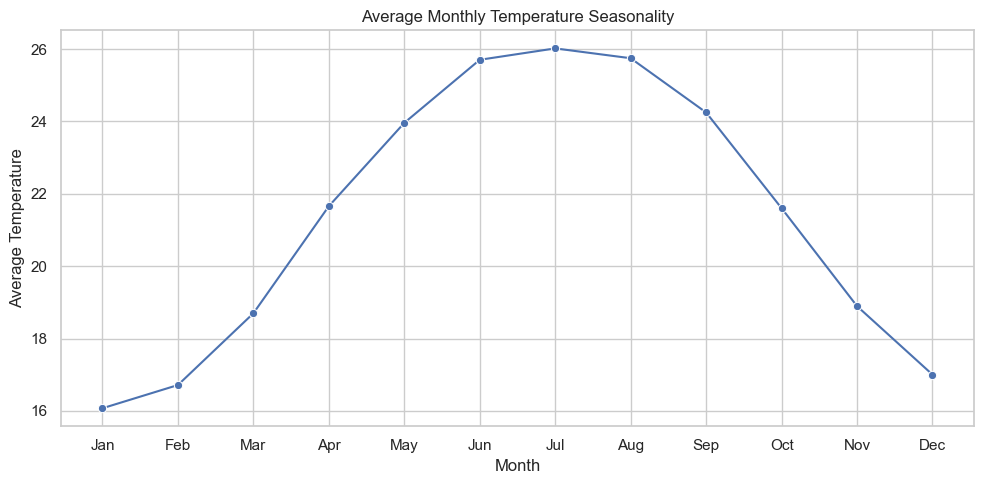

In [13]:
seasonality = eda.groupby("month", as_index=False)[temp_col].mean().sort_values("month")

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))
sns.lineplot(data=seasonality, x="month", y=temp_col, marker="o")
plt.title("Average Monthly Temperature Seasonality")
plt.xlabel("Month")
plt.ylabel("Average Temperature")
plt.xticks(ticks=range(1, 13), labels=month_labels)
plt.tight_layout()
plt.savefig(reports_dir / "eda_monthly_temperature_seasonality.png", dpi=150)
plt.show()

**Interpretation (Chart 4):**
- Peaks and troughs indicate expected seasonal cycles.
- Use this profile to justify yearly seasonality terms in forecasting models (e.g., Prophet baseline).

In [14]:
# Export summary
exported_files = [
    reports_dir / "eda_temperature_trend_by_region.html",
    reports_dir / "eda_precipitation_distribution_by_region.png",
    reports_dir / "eda_correlation_heatmap.png",
    reports_dir / "eda_correlation_surface_3d.html",
    reports_dir / "eda_monthly_temperature_seasonality.png",
]

for f in exported_files:
    print(f"{f.name}: {'OK' if f.exists() else 'MISSING'}")

eda_temperature_trend_by_region.html: OK
eda_precipitation_distribution_by_region.png: OK
eda_correlation_heatmap.png: OK
eda_correlation_surface_3d.html: OK
eda_monthly_temperature_seasonality.png: OK
